# Accuracy against known truth

A Monte Carlo simulation knows the true activity everywhere, so it can tell you how far a reconstruction is from the truth, not only how it looks. This tutorial reconstructs a SIMIND simulation of Lu-177 in a Jaszczak phantom, a cylinder of water with six hot spheres, with OSEM and with BSREM, and measures the bias and noise in each sphere and in the background after every iteration.

You will:

- turn SIMIND's noise-free projections into a realistic noisy acquisition,
- build sphere masks from the phantom's known geometry,
- record region statistics during reconstruction with a callback,
- compare the two algorithms with bias-noise curves.

In [1]:
from pytomography import datasets

# The tutorial data: downloaded the first time it runs (see Tutorial data in the docs)
datasets.fetch("SPECT/SIMIND-Jaszak")
DATA = datasets.data_dir()  # the PYTOMOGRAPHY_DATA folder, or ~/pytomography_data
# Results go here, never into the data folder
OUTPUT = datasets.output_dir("SPECT/SIMIND-Jaszak")

SPECT/SIMIND-Jaszak: already downloaded


In [2]:
import re
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pytomography
from pytomography.io.SPECT import simind
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.projectors.SPECT import SPECTSystemMatrix
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.algorithms import OSEM, BSREM
from pytomography.priors import RelativeDifferencePrior
from pytomography.callbacks import Callback

## 1. A noisy acquisition

SIMIND's projections are the expected counts per second when the phantom holds 1 MBq. Multiplying by the activity and by the time per projection gives the expected counts, and Poisson sampling gives one noisy acquisition. The two windows either side of the 208 keV photopeak give a triple-energy-window (TEW) estimate of the scatter in it.

In [3]:
path = DATA / 'SPECT' / 'SIMIND-Jaszak' / 'lu177_SYME_jaszak'
windows = {'photopeak': path / 'tot_w4.h00', 'lower': path / 'tot_w5.h00', 'upper': path / 'tot_w6.h00'}
object_meta, proj_meta = simind.get_metadata(str(windows['photopeak']))
activity = 1000        # MBq in the whole phantom
acquisition_time = 15  # seconds per projection

torch.manual_seed(0)
projections = {w: torch.poisson(simind.get_projections(str(p)) * activity * acquisition_time)
               for w, p in windows.items()}
photopeak = projections['photopeak']
widths = {w: simind.get_energy_window_width(str(p)) for w, p in windows.items()}
scatter = simind.compute_EW_scatter(projections['lower'], projections['upper'],
                                    widths['lower'], widths['upper'], widths['photopeak'])
print(f"{photopeak.sum().item():.3g} counts in the photopeak window")

1e+07 counts in the photopeak window


## 2. The truth: sphere masks and concentrations

SIMIND writes the phantom's sources to `results.res`: the volume of each sphere and of the background. Every sphere holds the same concentration, ten times the background's (the simulation's `BG:0.1` setting), so the activity in the phantom fixes both concentrations.

The sphere masks come with the dataset, on SIMIND's grid of 512 × 512 × 512 voxels of 1.2 mm, labelled 1 (the largest sphere) to 6 (the smallest) like SIMIND's sources. Averaging blocks of 4 × 4 × 4 voxels gives, for each voxel of the 128 × 128 × 128 reconstruction grid (4.8 mm), the fraction a sphere fills; a voxel belongs to the sphere when the sphere fills more than half of it. The background region is the water at least three voxels from the wall and from every sphere, where the partial-volume effect is small.

In [4]:
block = (path / 'results.res').read_text(errors='replace').split('MULTIPLE SOURCE CONFIGURATION')[1].split('-----')[0]
volume_mL = {('background' if name == 'BKG' else f'sphere {name}'): float(v)
             for name, v in re.findall(r'^\s+(\d+|BKG)\s+([\d.]+)', block, re.M)}
sphere_MBq_per_mL = activity / (sum(v for r, v in volume_mL.items() if r != 'background') + 0.1 * volume_mL['background'])
truth_MBq_per_mL = {r: sphere_MBq_per_mL * (0.1 if r == 'background' else 1) for r in volume_mL}

labels = torch.from_numpy(np.load(path.parent / 'jaszak_spheres.npz')['labels'])  # 0 outside the spheres
masks = {}
for k in range(1, 7):
    fraction = F.avg_pool3d((labels == k).float()[None, None], kernel_size=4)[0, 0]
    masks[f'sphere {k}'] = (fraction > 0.5).to(pytomography.device)

attenuation_map = simind.get_attenuation_map(str(path / 'amap.hct'))
water = attenuation_map > 0.5 * attenuation_map.max()
dilate = lambda mask: F.max_pool3d(mask.float()[None, None], 7, stride=1, padding=3)[0, 0] > 0
erode = lambda mask: ~dilate(~mask)
spheres = torch.stack(list(masks.values())).any(0)
masks['background'] = erode(water) & ~dilate(spheres)

regions = list(masks)
for r in regions:
    print(f"{r:10s} {volume_mL[r]:8.2f} mL  {int(masks[r].sum()):6d} voxels  truth {truth_MBq_per_mL[r]:.3f} MBq/mL")

sphere 1      28.73 mL     248 voxels  truth 1.466 MBq/mL
sphere 2      16.84 mL     143 voxels  truth 1.466 MBq/mL
sphere 3       8.58 mL      73 voxels  truth 1.466 MBq/mL
sphere 4       3.65 mL      26 voxels  truth 1.466 MBq/mL
sphere 5       2.10 mL      17 voxels  truth 1.466 MBq/mL
sphere 6       0.45 mL       2 voxels  truth 1.466 MBq/mL
background  6220.00 mL   25408 voxels  truth 0.147 MBq/mL


## 3. System matrix and likelihood

The system matrix models attenuation, from the attenuation map SIMIND used, and the collimator-detector response, from the collimator in the SIMIND header. The scatter estimate enters the Poisson likelihood as an additive term.

In [5]:
psf_meta = simind.get_psfmeta_from_header(str(windows['photopeak']))
system_matrix = SPECTSystemMatrix(
    obj2obj_transforms=[SPECTAttenuationTransform(attenuation_map), SPECTPSFTransform(psf_meta)],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta)
likelihood = PoissonLogLikelihood(system_matrix, photopeak, additive_term=scatter)

## 4. Region statistics during reconstruction

A callback runs after every sub-iteration and returns the object, which the algorithm keeps. This one records, at the end of each iteration, the mean and standard deviation of the voxel values in each region.

In [6]:
class RegionStatistics(Callback):
    def __init__(self, masks, n_subsets):
        self.masks = masks
        self.n_subsets = n_subsets
        self.mean = {region: [] for region in masks}
        self.std = {region: [] for region in masks}

    def run(self, object, n_iter, n_subset):
        if n_subset == self.n_subsets - 1:  # last subset: the end of an iteration
            for region, mask in self.masks.items():
                values = object[mask]
                self.mean[region].append(values.mean().item())
                self.std[region].append(values.std().item())
        return object

## 5. Reconstruct with OSEM and BSREM

BSREM adds a relative difference prior, which penalises differences between neighbouring voxels relative to their values, so it smooths noise without washing out edges as much as a quadratic prior. Both run for 40 iterations of 8 subsets.

In [7]:
n_iters, n_subsets = 40, 8

t0 = time.time()
stats_osem = RegionStatistics(masks, n_subsets)
recon_osem = OSEM(likelihood)(n_iters=n_iters, n_subsets=n_subsets, callback=stats_osem)
print(f"OSEM:  {time.time() - t0:.1f} s")

t0 = time.time()
stats_bsrem = RegionStatistics(masks, n_subsets)
bsrem = BSREM(likelihood, prior=RelativeDifferencePrior(beta=0.3, gamma=2), relaxation_sequence=lambda n: 1 / (n / 50 + 1))
recon_bsrem = bsrem(n_iters=n_iters, n_subsets=n_subsets, callback=stats_bsrem)
print(f"BSREM: {time.time() - t0:.1f} s")

OSEM:  5.1 s


BSREM: 8.2 s


## 6. From counts to activity

Reconstructed values are counts per voxel. One calibration factor, the activity in the phantom divided by the total reconstructed counts, turns them into MBq per voxel, and dividing by the voxel volume gives MBq/mL. On a real scanner the factor comes from imaging a source of known activity.

In [8]:
voxel_mL = float(np.prod(object_meta.dr))  # SPECT voxel sizes are in cm

def bias_and_noise(stats, recon, region):
    """Bias and noise of a region at every iteration, in percent of its true concentration."""
    to_MBq_per_mL = activity / recon.sum().item() / voxel_mL
    mean = np.array(stats.mean[region]) * to_MBq_per_mL
    std = np.array(stats.std[region]) * to_MBq_per_mL
    truth = truth_MBq_per_mL[region]
    return 100 * (mean / truth - 1), 100 * std / truth

for region in regions:
    b_osem, n_osem = bias_and_noise(stats_osem, recon_osem, region)
    b_bsrem, n_bsrem = bias_and_noise(stats_bsrem, recon_bsrem, region)
    print(f"{region:10s} after {n_iters} iterations: OSEM bias {b_osem[-1]:+6.1f}% noise {n_osem[-1]:5.1f}%   "
          f"BSREM bias {b_bsrem[-1]:+6.1f}% noise {n_bsrem[-1]:5.1f}%")

sphere 1   after 40 iterations: OSEM bias  -13.6% noise  37.4%   BSREM bias  -21.1% noise  31.1%
sphere 2   after 40 iterations: OSEM bias  -13.1% noise  36.3%   BSREM bias  -24.3% noise  29.7%
sphere 3   after 40 iterations: OSEM bias  -20.7% noise  43.6%   BSREM bias  -35.8% noise  25.6%
sphere 4   after 40 iterations: OSEM bias  -23.4% noise  50.5%   BSREM bias  -54.1% noise  14.1%
sphere 5   after 40 iterations: OSEM bias  -36.3% noise  36.0%   BSREM bias  -67.7% noise   7.1%
sphere 6   after 40 iterations: OSEM bias  -64.5% noise   6.4%   BSREM bias  -86.9% noise   0.1%
background after 40 iterations: OSEM bias   -0.3% noise  37.7%   BSREM bias   +0.8% noise   5.9%


## 7. Bias and noise in each region

Each point is one iteration, starting at the open circle. A perfect reconstruction would sit at zero bias and zero noise.

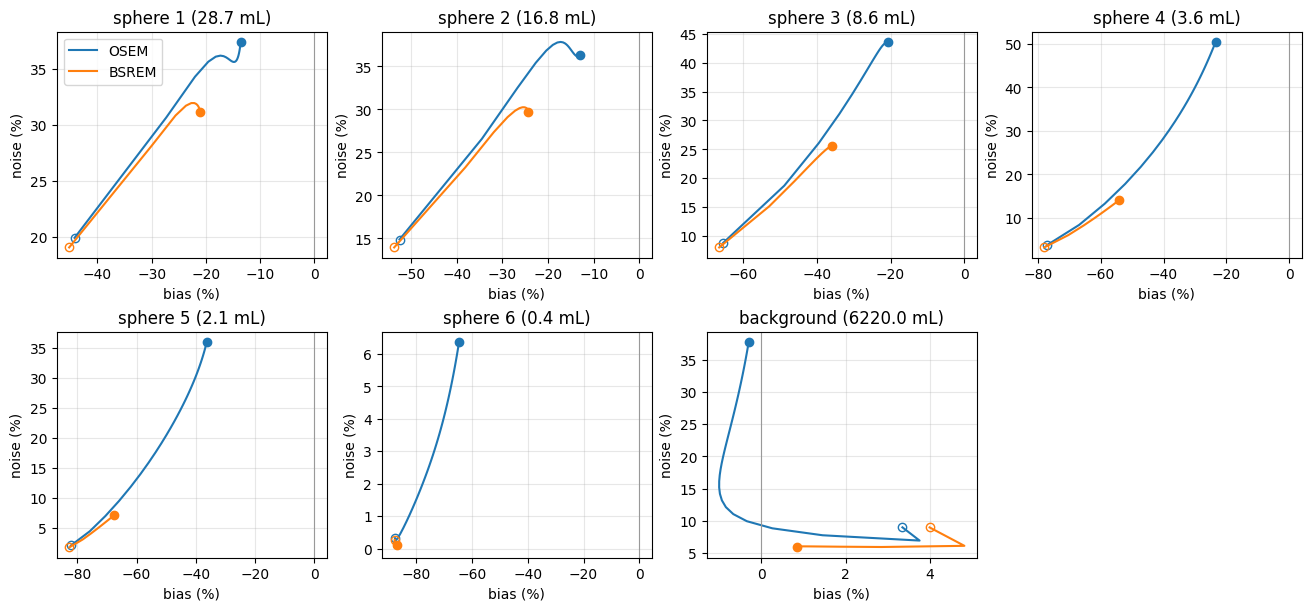

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6), constrained_layout=True)
for ax, region in zip(axes.ravel(), regions):
    for stats, recon, name, color in [(stats_osem, recon_osem, 'OSEM', 'tab:blue'), (stats_bsrem, recon_bsrem, 'BSREM', 'tab:orange')]:
        bias, noise = bias_and_noise(stats, recon, region)
        ax.plot(bias, noise, '-', color=color, lw=1.5, label=name)
        ax.plot(bias[0], noise[0], 'o', mfc='none', color=color)
        ax.plot(bias[-1], noise[-1], 'o', color=color)
    ax.axvline(0, color='0.6', lw=0.8)
    ax.set_title(f'{region} ({volume_mL[region]:.1f} mL)')
    ax.set_xlabel('bias (%)')
    ax.set_ylabel('noise (%)')
    ax.grid(alpha=0.3)
axes[0, 0].legend()
axes[-1, -1].axis('off')
plt.show()

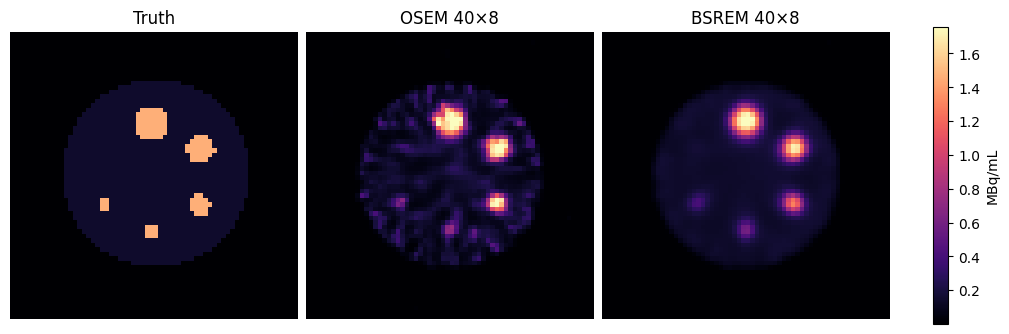

In [10]:
z = int(torch.nonzero(spheres)[:, 2].float().mean())  # the slice through the spheres' centres
truth_image = (water.float() * truth_MBq_per_mL['background']
               + spheres.float() * (sphere_MBq_per_mL - truth_MBq_per_mL['background'])).cpu()
images = [truth_image,
          recon_osem.cpu() * activity / recon_osem.sum().item() / voxel_mL,
          recon_bsrem.cpu() * activity / recon_bsrem.sum().item() / voxel_mL]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), constrained_layout=True)
for ax, image, title in zip(axes, images, ['Truth', f'OSEM {n_iters}×{n_subsets}', f'BSREM {n_iters}×{n_subsets}']):
    im = ax.imshow(image[32:96, 32:96, z].T, cmap='magma', origin='lower', vmax=1.2 * sphere_MBq_per_mL)
    ax.set_title(title)
    ax.axis('off')
fig.colorbar(im, ax=axes, shrink=0.8, label='MBq/mL')
plt.show()

Every sphere reads low, and the smaller the sphere, the lower: after 40 iterations OSEM recovers about 85% of the concentration in the largest sphere but only about a third in the smallest, which covers two voxels of the reconstruction grid. The scanner's resolution spreads each sphere's counts into the water around it (the partial-volume effect). More OSEM iterations bring the spheres closer to the truth but make the image noisier, until the voxel-to-voxel variation in the background reaches almost 40% of its value. BSREM keeps the background as accurate as OSEM does, within a few percent, with about a sixth of the noise; its smoothing adds to the partial-volume loss, so every sphere ends lower than with OSEM, the small ones most of all.

## Next steps

- Shorten `acquisition_time` to see how bias and noise change at low counts.
- Try other priors and values of `beta` in BSREM, or the other algorithms in the [algorithms tutorial](t_algorithms.ipynb).
- Use the same callback with your own phantom: all it needs is a mask and a true concentration for each region.